# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hist
import mplhep as hep


from rich import print
from matplotlib.colors import LogNorm
from tpvalidator.analysis.histograms import cumsum_hist, cut_scan_to_df, compute_regaxis_specs, make_regaxis, build_histogram

from tpvalidator.viz.tps import TrgPrimitivesPlotter
from tpvalidator.viz.backtracker import BackTrackerPlotter
from tpvalidator.viz.display import TriggerPrimitivesEventViewer
from typing import Literal


# Analysis

In [3]:
class TPFilterAnalyser:
    
    def __init__(self, bkg_ws, sig_ws):
        self._bkd_ws = bkg_ws
        self._sig_ws = sig_ws


# Data

In [4]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'radbkg']
datasets = dctl.load('data/vd/1x8x14/3sig', load_rawadc=False, selection=dataset_names)
rad_ws=datasets['radbkg']
em_ws=datasets['eminus']


Workspace ar39 skipped

Workspace ar39_5e_00 skipped

Loading radbkg

Dataset 'radbkg': 10 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Loading eminus

Dataset 'eminus': 1000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

# Introduction

TP filtering is applied to reduce the rate of TPs at the input of the TriggerActivity maker algorithm(s).
This is possible becasue a large fraction of the input TPs are from Ar39 decays: they are evenly distributed across in space and time, low in energy (Ar39 e- endpoing at 0.5 MeV).
They do not contribute to or give rise to any deposit with significant energy or extension.
Vice-versa target signals (primarily electrons) in the low-MeV energy range give rise to multi TP, high(er) energy clusters

# Pre-filtering TP rates

The rate of trigger primitives by generator, with only TP threshold cut applied is the following:

In [5]:
rad_tpp = TrgPrimitivesPlotter(rad_ws)

In [6]:
print(rad_tpp.make_generator_activity_table('adc_peak >= 45 & readout_plane_id == 2', norm='rate', det_geo='crp'))


                  Rates per generator (crp)                   
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃    ┃ generator                               ┃ rate        ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 3  │ CavernwallGammasAtLAr1x8x14             │ 52152.94 HZ │
│ 1  │ Ar39GenInLAr                            │ 48217.65 HZ │
│ 8  │ Kr85GenInLAr                            │ 6684.87 HZ  │
│ 0  │ DetSimElecNoise                         │ 2394.96 HZ  │
│ 22 │ foamGammasAtLAr1x8x14                   │ 2098.32 HZ  │
│ 19 │ Th232ChainGenInCathode                  │ 1563.87 HZ  │
│ 18 │ Th232ChainGenInAnode                    │ 1503.36 HZ  │
│ 20 │ U238ChainGenInAnode                     │ 619.33 HZ   │
│ 21 │ U238ChainGenInCathode                   │ 369.75 HZ   │
│ 11 │ Rn222ChainBi214GenInLAr                 │ 174.79 HZ   │
│ 13 │ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 114.29 HZ   │
│ 9  │ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 104.20 HZ   │
│ 4  │ K40GenInAnode                           │ 94.96 HZ    │
│ 5  │ K40GenInCathode                         │ 73.11 HZ    │
│ 10 │ Rn220ChainPb212GenInLAr                 │ 61.34 HZ    │
│ 15 │ Rn222ChainPb214GenInLAr                 │ 49.58 HZ    │
│ 12 │ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 41.18 HZ    │
│ 7  │ K42From42ArGenInUpperMesh1x8x14         │ 25.21 HZ    │
│ 14 │ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 17.65 HZ    │
│ 2  │ Ar42GenInLAr                            │ 6.72 HZ     │
│ 17 │ Rn222ChainRn222GenInLAr                 │ 3.36 HZ     │
│ 16 │ Rn222ChainPo218GenInLAr                 │ 2.52 HZ     │
│ 6  │ K42From42ArGenInLAr                     │ 1.68 HZ     │
└────┴─────────────────────────────────────────┴─────────────┘

# Background TPs properties

The TP variables distributions for highest backgrounds are:

In [7]:
var_specs={
    'samples_over_threshold': {'name':'samples_over_threshold', 'bin_size':1, 'label': 'Samples Over Threshold'},
    'adc_peak': {'name':'adc_peak', 'bin_size':10, 'label': 'ADC Peak'},
    'adc_integral':{'name':'adc_integral', 'bin_size':10, 'label': 'ADC Integral'}
}

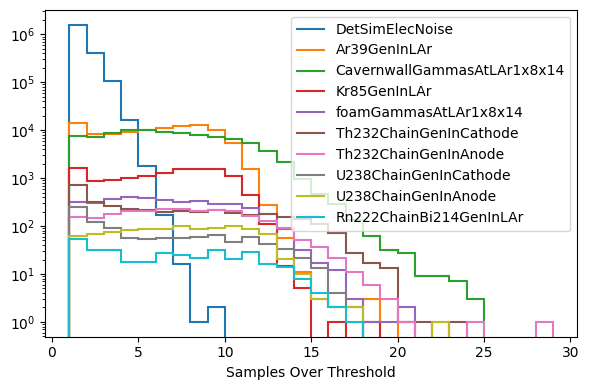

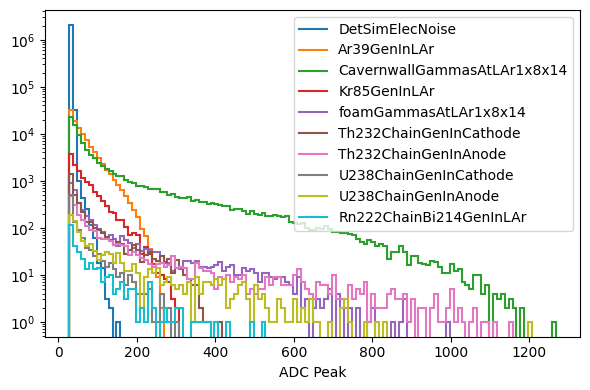

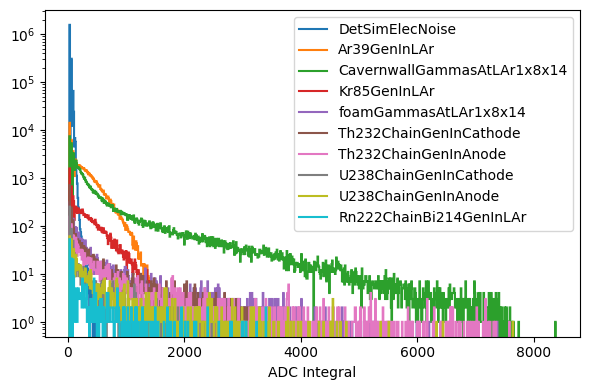

In [8]:
figsize=(6,4)
# query='adc_peak > 45 & samples_over_threshold > 9'
query=None
fig = rad_tpp.plot_var_by_generator(query=query, rop=2, var_spec=var_specs['samples_over_threshold'], figsize=figsize)
fig = rad_tpp.plot_var_by_generator(query=query, rop=2, var_spec=var_specs['adc_peak'], figsize=figsize)
fig = rad_tpp.plot_var_by_generator(query=query, rop=2, var_spec=var_specs['adc_integral'], figsize=figsize)

## Notes and Observations

- These plots use backtracked TPs. Backtracking has known inefficiencies.
- Ar39 and Kr85 are both concentrated at low samples osve thresholds, peaking at $SOT \simeq 9$, and falling sharply just above $SOT > 10$.
  

# Single Electrons sample

In [9]:
em_tpp = TrgPrimitivesPlotter(em_ws)

In [10]:
var_specs={
    'samples_over_threshold': {'name':'samples_over_threshold', 'bin_size':3, 'label': 'Samples Over Threshold'},
    'adc_peak': {'name':'adc_peak', 'bin_size':10, 'label': 'ADC Peak'},
    'adc_integral':{'name':'adc_integral', 'bin_size':10, 'label': 'ADC Integral'}
}

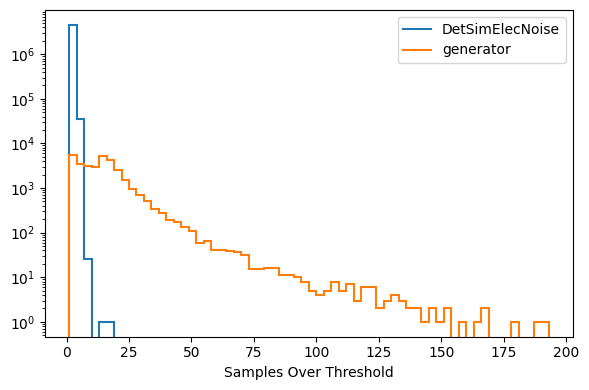

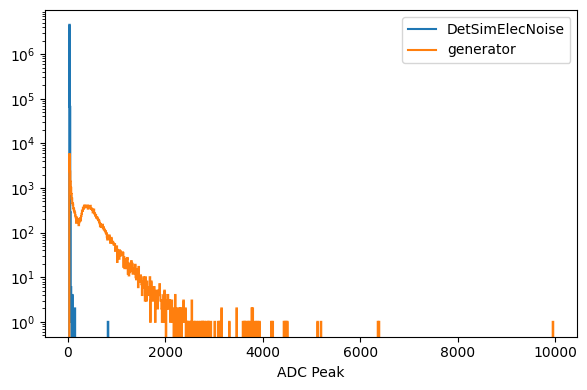

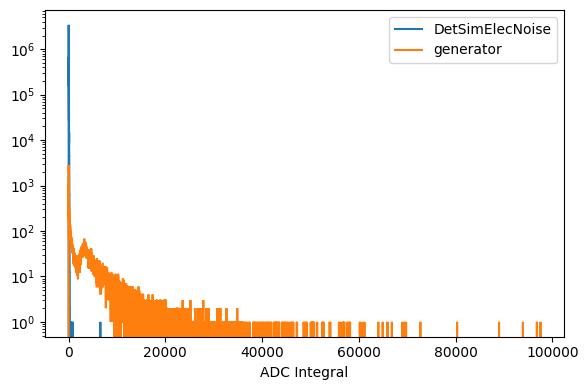

In [11]:
query=None
fig = em_tpp.plot_var_by_generator(query=query, rop=2, var_spec=var_specs['samples_over_threshold'], figsize=figsize)
fig = em_tpp.plot_var_by_generator(query=query, rop=2, var_spec=var_specs['adc_peak'], figsize=figsize)
fig = em_tpp.plot_var_by_generator(query=query, rop=2, var_spec=var_specs['adc_integral'], figsize=figsize)

# TO DEV